## EDA

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from collections import defaultdict
import random
from torch.utils.data import Dataset
from PIL import Image

Testing: {'pituitary': 400, 'notumor': 400, 'glioma': 400, 'meningioma': 400}
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training set size: 4480
Validation set size: 1120

Original distribution:
Counter({'pituitary': 1400, 'notumor': 1400, 'glioma': 1400, 'meningioma': 1400})

Training distribution:
Counter({'pituitary': 1120, 'notumor': 1120, 'glioma': 1120, 'meningioma': 1120})

Validation distribution:
Counter({'glioma': 280, 'meningioma': 280, 'pituitary': 280, 'notumor': 280})


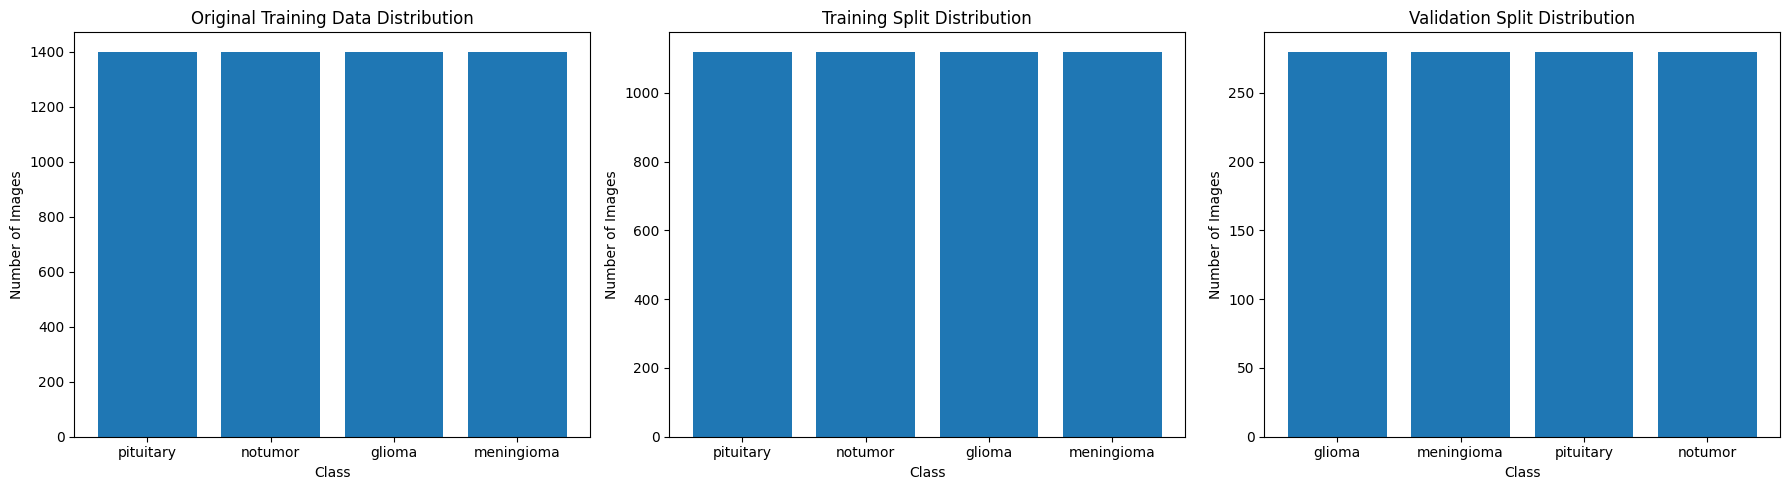

In [15]:
train_dir = "MRI/Training"
test_dir = "MRI/Testing"

# ---------------------------
# Count testing set per class
# ---------------------------

test_paths =  []
test_labels = []

test_classes = [
    cls for cls in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, cls))
]

for label in test_classes:
    class_path = os.path.join(test_dir, label)
    
    for img_name in os.listdir(class_path):
        test_paths.append(os.path.join(class_path, img_name))
        test_labels.append(label)

test_class_counts = {
    cls: len(os.listdir(os.path.join(test_dir, cls)))
    for cls in test_classes
}

print("Testing:", test_class_counts)

# ---------------------------
# Collect training image paths and labels
# ---------------------------
image_paths = []
labels = []

train_classes = [
    cls for cls in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, cls))
]

for label in train_classes:
    class_path = os.path.join(train_dir, label)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        image_paths.append(img_path)
        labels.append(label)

# ---------------------------
# Stratified split
# ---------------------------
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)


# ---------------------------
# Create train and validation datasets
# ---------------------------

class MRIDataset(Dataset):
    def __init__(self, paths, labels, label_to_idx, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.label_to_idx = label_to_idx
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("L")
        label = self.label_to_idx[self.labels[idx]]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
classes = sorted(set(labels))   # labels = original full dataset labels
label_to_idx = {cls: i for i, cls in enumerate(classes)}

print(label_to_idx)


# ---------------------------
# Count class distributions
# ---------------------------
original_counts = Counter(labels)
train_class_counts = Counter(train_labels)
val_class_counts = Counter(val_labels)

print("Training set size:", len(train_paths))
print("Validation set size:", len(val_paths))

print("\nOriginal distribution:")
print(original_counts)

print("\nTraining distribution:")
print(train_class_counts)

print("\nValidation distribution:")
print(val_class_counts)

# ---------------------------
# Plot distributions
# ---------------------------
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.bar(original_counts.keys(), original_counts.values())
plt.title("Original Training Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.subplot(1, 3, 2)
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.title("Training Split Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.subplot(1, 3, 3)
plt.bar(val_class_counts.keys(), val_class_counts.values())
plt.title("Validation Split Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

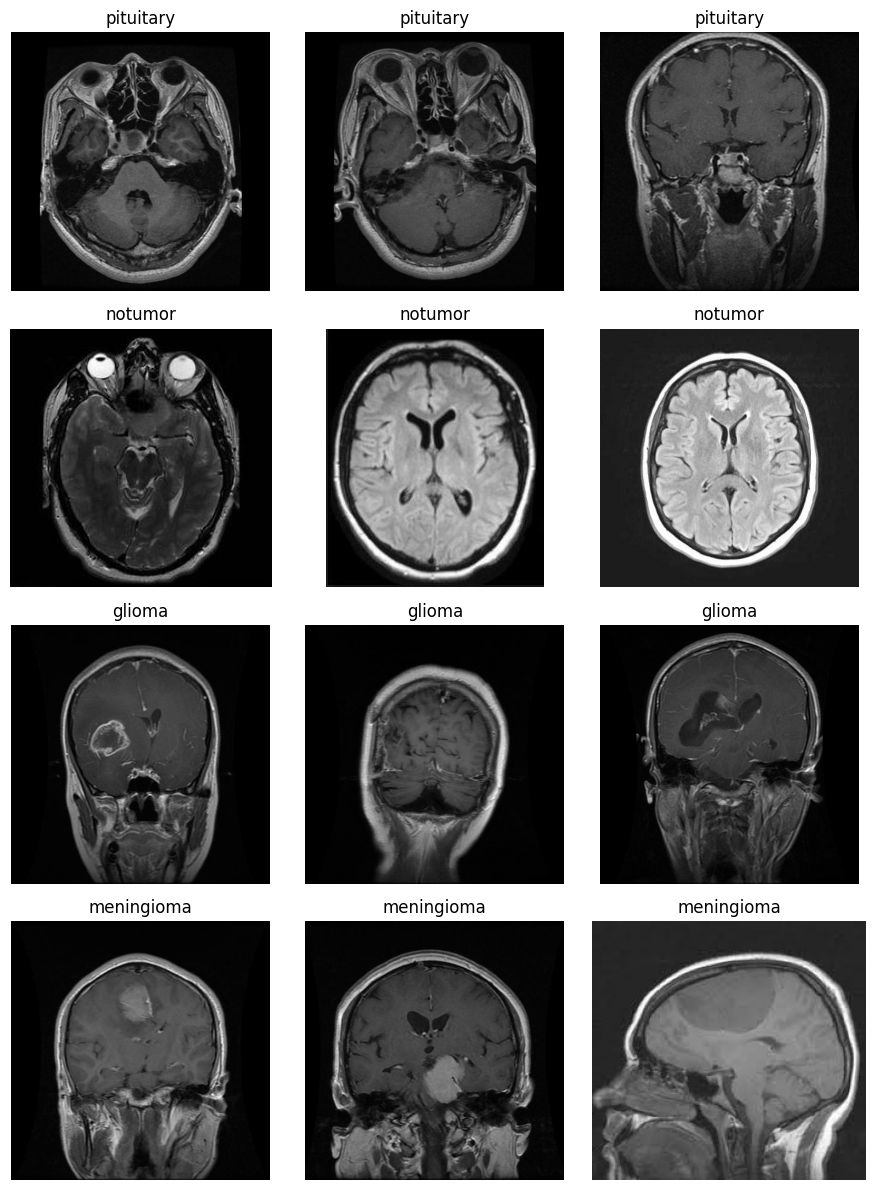

In [16]:
def show_random_images(paths, labels, num_per_class=3):
    
    # group images by class
    class_to_images = defaultdict(list)
    
    for path, label in zip(paths, labels):
        class_to_images[label].append(path)
    
    classes = list(class_to_images.keys())
    
    plt.figure(figsize=(num_per_class * 3, len(classes) * 3))
    
    plot_index = 1
    
    for cls in classes:
        images = class_to_images[cls]
        
        selected = random.sample(images, min(len(images), num_per_class))
        
        for img_path in selected:
            img = Image.open(img_path)
            
            plt.subplot(len(classes), num_per_class, plot_index)
            plt.imshow(img, cmap='gray')
            plt.title(cls)
            plt.axis('off')
            
            plot_index += 1
    
    plt.tight_layout()
    plt.show()

show_random_images(train_paths, train_labels, num_per_class=3)

In [ ]:
# train_dataset = MRIDataset(train_paths, train_labels)
# val_dataset   = MRIDataset(val_paths, val_labels)


# sizes = []

# for cls in train_classes:
#     folder = os.path.join(train_dir, cls)
#     for img_name in os.listdir(folder)[:50]:  # only check the first 50 images of each class
#         img_path = os.path.join(folder, img_name)
#         img = Image.open(img_path)
#         sizes.append(img.size)

# print(set(sizes))

# img = Image.open(img_path)
# print(img.mode)

# arr = np.array(img)

# print(arr.shape)  # (H, W, 3)
# print((arr[:,:,0] == arr[:,:,1]).all())
# print((arr[:,:,1] == arr[:,:,2]).all())

{(630, 630), (350, 350), (214, 236), (235, 277), (206, 244), (235, 228), (232, 217), (236, 300), (200, 252), (512, 512), (201, 251), (227, 300), (251, 273), (441, 427), (1338, 1304), (600, 600), (256, 256), (439, 512), (196, 257), (359, 449), (201, 250), (192, 192), (229, 214), (494, 600), (150, 198), (755, 824), (468, 444), (227, 262), (236, 280), (225, 225), (233, 226), (315, 341), (230, 282), (218, 231)}
RGB
(512, 512, 3)
True
True


## Data Preprocessing

In [34]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms

testset shape: torch.Size([1, 224, 224])
trainset shape: torch.Size([1, 224, 224])
valset shape: torch.Size([1, 224, 224])
train_labels[0] = pituitary
decoded label   = pituitary
val_labels[0]   = glioma
decoded label   = glioma
test_labels[0]  = pituitary
decoded label   = pituitary


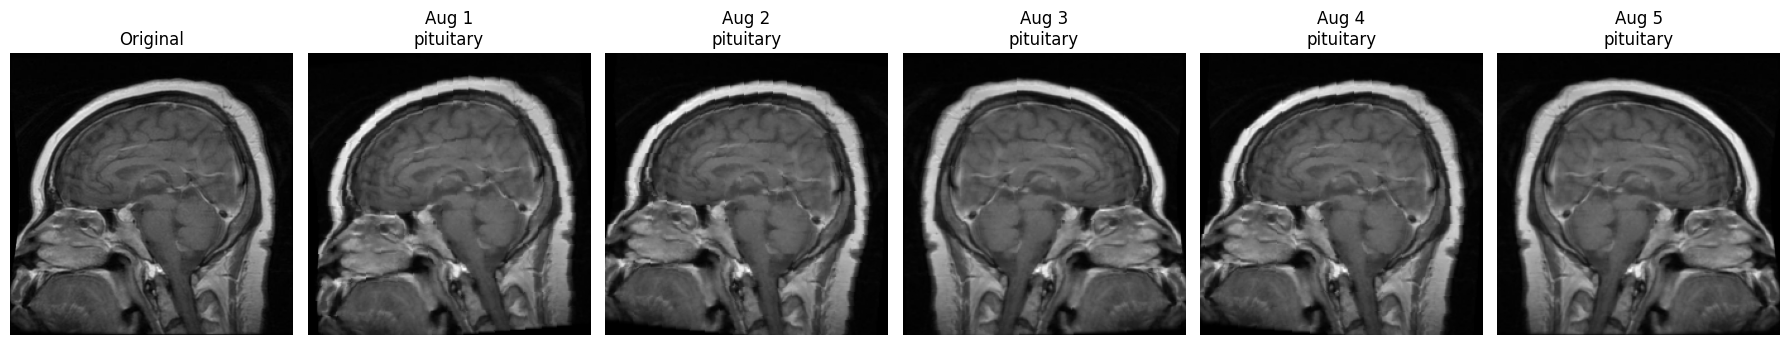

Same label: True
Exactly same tensor: False


In [23]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),      # augmentation
    transforms.RandomHorizontalFlip(),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),      # only preprocessing
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = MRIDataset(
    train_paths,
    train_labels,
    label_to_idx,
    transform=train_transform   
)

val_dataset = MRIDataset(
    val_paths,
    val_labels,
    label_to_idx,
    transform=val_transform    
)

test_dataset = MRIDataset(
    test_paths,
    test_labels,
    label_to_idx,     
    transform=test_transform
)


# check shape 

img, label = test_dataset[0]

print("testset shape:", img.shape)   # [1, 224, 224]


img, label = train_dataset[0]

print("trainset shape:", img.shape)   # should be [1, 224, 224]


img, label = val_dataset[0]

print("valset shape:", img.shape)   # should be [1, 224, 224]

# check label decoding

idx_to_label = {v: k for k, v in label_to_idx.items()}
# train
img, label_num = train_dataset[0]
print("train_labels[0] =", train_labels[0])
print("decoded label   =", idx_to_label[label_num])

# val
img, label_num = val_dataset[0]
print("val_labels[0]   =", val_labels[0])
print("decoded label   =", idx_to_label[label_num])

# test
img, label_num = test_dataset[0]
print("test_labels[0]  =", test_labels[0])
print("decoded label   =", idx_to_label[label_num])

# check augmentation
def show_augmentation(dataset, paths, index=0, num_versions=5):
    original_img = Image.open(paths[index])

    plt.figure(figsize=(3 * (num_versions + 1), 4))

    # original
    plt.subplot(1, num_versions + 1, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # augmented versions
    for i in range(num_versions):
        img, label = dataset[index]

        # undo normalization for display
        img = img * 0.5 + 0.5
        img = img.squeeze().numpy()

        plt.subplot(1, num_versions + 1, i + 2)
        plt.imshow(img, cmap='gray')
        plt.title(f"Aug {i+1}\n{idx_to_label[label]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_augmentation(train_dataset, train_paths, index=0, num_versions=5)

img1, label1 = train_dataset[0]
img2, label2 = train_dataset[0]

print("Same label:", label1 == label2)
print("Exactly same tensor:", (img1 == img2).all().item())

## Baseline Model

In [7]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, 4)  # 4 classes
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [8]:
import torch.optim as optim

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
for epoch in range(10):
    for images, labels in train_loader:
        
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.4903984069824219


KeyboardInterrupt: 